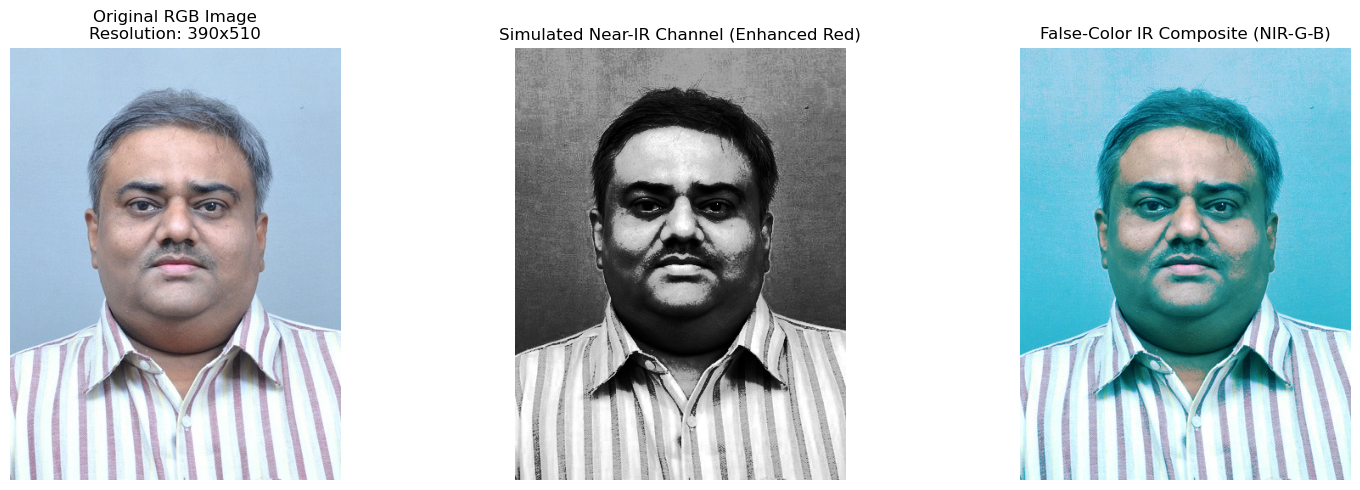

In [ ]:
# Re-run Step 1 and Step 2 together for clarity

# Step 1: Load the image and check resolution
image_path = "C:\\Users\\ysang\\Downloads\\WhatsApp Image 2025-06-02 at 15.56.13_56e5b7cb.jpg"
img = cv2.imread(image_path)
height, width, channels = img.shape

# Convert to RGB for visualization with matplotlib
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Step 2: Preprocessing - Channel separation and NIR simulation
R, G, B = cv2.split(img_rgb)
nir_sim = cv2.equalizeHist(R)  # Simulated Near-Infrared channel

# False-color IR composite: NIR in Red, G in Green, B in Blue
false_color_ir = cv2.merge([nir_sim, G, B])

# Plot all three stages
fig, axs = plt.subplots(1, 3, figsize=(16, 5))

axs[0].imshow(img_rgb)
axs[0].set_title(f"Original RGB Image\nResolution: {width}x{height}")
axs[0].axis('off')

axs[1].imshow(nir_sim, cmap='gray')
axs[1].set_title("Simulated Near-IR Channel (Enhanced Red)")
axs[1].axis('off')

axs[2].imshow(false_color_ir)
axs[2].set_title("False-Color IR Composite (NIR-G-B)")
axs[2].axis('off')

plt.tight_layout()
plt.show()


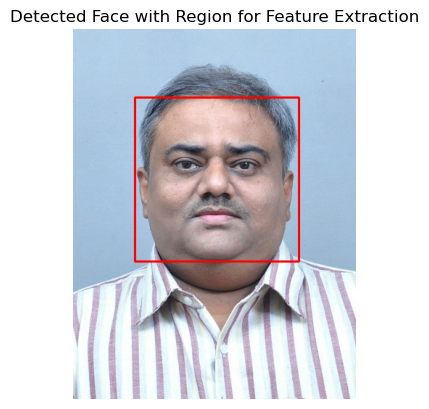

[('Left Cheek', 156.6301191362621, 26.097103904974926),
 ('Right Cheek', 155.7451600893522, 25.159728471091995)]

In [10]:
# Step 3: Detect face and extract basic skin region features using Haar Cascade

# Load Haar Cascade for face detection
haar_cascade_path = cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
face_cascade = cv2.CascadeClassifier(haar_cascade_path)

# Convert image to grayscale for detection
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Detect faces
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

# Draw rectangle and extract features if face found
output_img = img_rgb.copy()
feature_data = []

for (x, y, w, h) in faces:
    # Draw face rectangle
    cv2.rectangle(output_img, (x, y), (x + w, y + h), (255, 0, 0), 2)

    # Define cheek region (roughly lower-left and lower-right parts of face box)
    left_cheek = gray[y + h//2 : y + int(0.85*h), x + int(0.1*w) : x + int(0.4*w)]
    right_cheek = gray[y + h//2 : y + int(0.85*h), x + int(0.6*w) : x + int(0.9*w)]

    for region, label in zip([left_cheek, right_cheek], ['Left Cheek', 'Right Cheek']):
        mean_intensity = np.mean(region)
        contrast = np.std(region)
        feature_data.append((label, mean_intensity, contrast))

# Show image with face box
plt.imshow(output_img)
plt.title("Detected Face with Region for Feature Extraction")
plt.axis('off')
plt.show()

feature_data


In [11]:
import pandas as pd

# Step 4: Export feature data to CSV
# We assume `feature_data` is from Step 3 and contains tuples of (Region, Mean, Contrast)

# Convert to DataFrame
df_features = pd.DataFrame(feature_data, columns=["Region", "Mean Intensity", "Contrast"])

# Define output path
output_csv_path = "C:\\Users\\ysang\\Downloads\\cheek_feature_analysis.csv"

# Save to CSV
df_features.to_csv(output_csv_path, index=False)

# Display the saved DataFrame
df_features


,Region,Mean Intensity,Contrast
0,Left Cheek,156.630119,26.097104
1,Right Cheek,155.745160,25.159728
